## Imports

In [ ]:
# Imports
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [201]:
# Read excel file
df = pd.read_excel('integrated_data_with_sic.xlsx')
print(df.shape)

(16753, 37)


##  Preprocessing Part

#### Add variables 15_24, 15_64, covid

In [202]:

# Combine year + Quarter
df['quarter'] = df['quarter'].str.extract('(\d+)').astype(int)
df['year_quarter'] = df['year']*10 + df['quarter']

# Add productive population (15 ~ 24, 15 ~ 64) 경제 활동인구 
a15_64 = [24900.33333, 25418.66667, 25224.33333, 25249.33333, 25288, 25803.66667, 25731, 25494.66667, 25346.33333,
          25790.66667, 25632, 25552.66667, 25398.66667, 25702.33333, 25429.66667, 25359.66667]
a15_24 = [1480, 1582.666667, 1546, 1466.666667, 1560.666667, 1607.333333, 1564, 1439.333333, 1475.666667, 1470.666667, 1456.333333,
          1389.666667, 1387, 1405.666667, 1341.333333, 1259.666667]
a15_64 = list(map(int, a15_64))
a15_24 = list(map(int, a15_24))

df['a15_64'] = df.apply(lambda row: a15_64[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)
df['a15_24'] = df.apply(lambda row: a15_24[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)

# Add Covid-19 data

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
covid_data = pd.read_csv(url)
covid_data["date"] = pd.to_datetime(covid_data["date"])

korea = covid_data[covid_data["location"] == "South Korea"].copy()
korea = korea[(korea["date"] >= "2021-01-01") & (korea["date"] <= "2024-12-31")]
korea_indexed = korea.set_index('date')
korea_quarterly = korea_indexed.resample('QE').mean(numeric_only=True)
#  'reproduction_rate' 도 고려해볼만 함 (감영 재생산 지수)
korea_quarterly = korea_quarterly['new_cases_per_million'].astype(int).to_numpy()
korea_quarterly = np.append(korea_quarterly, 0)
print(korea_quarterly)

df['covid'] = df.apply(lambda row: korea_quarterly[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)

[   9   11   31   64 2444 1342 1320  847  452  265  535    0    0    0
    0    0]


#### remove TimeSeries nan companies

In [203]:
# Handling Missing Values 

# 시계열이 누락된 기업 제거
all_quarters = sorted(df['year_quarter'].unique())
missing_dict = {}

for company, group in df.groupby('company_name'):
    existing = set(group['year_quarter'])
    missing = set(all_quarters) - existing
    
    if missing:  # 하나라도 빠졌다면
        missing_dict[company] = sorted(missing)

remove_list = list(missing_dict.keys())
df_clean = df[~df['company_name'].isin(remove_list)]
print(df_clean.shape) 

(15648, 40)


#### Handeling Computable Missing values (오차 없이 확정적으로 채울 수 있는 경우)

In [204]:
# Handling missing total_liabilities
total_liabilities_mask = df_clean['total_liabilities'].isnull() & df_clean['total_assets'].notnull() & df_clean['total_equity'].notnull()
df_clean.loc[total_liabilities_mask, 'total_liabilities'] = df_clean.loc[total_liabilities_mask, 'total_assets'] - df_clean.loc[total_liabilities_mask, 'total_equity']

# Handling missing total_equity
total_equity_mask = df_clean['total_equity'].isnull() & df_clean['total_assets'].notnull() & df_clean['total_liabilities'].notnull()
df_clean.loc[total_equity_mask, 'total_equity'] = df_clean.loc[total_equity_mask, 'total_assets'] - df_clean.loc[total_equity_mask, 'total_liabilities']

# Handling missing dept_ratio
dept_ratio_mask = df_clean['debt_ratio'].isnull() & df_clean['total_equity'].notnull() & df_clean['total_liabilities'].notnull()
df_clean.loc[dept_ratio_mask, 'debt_ratio'] = (df_clean.loc[dept_ratio_mask, 'total_liabilities'] / df_clean.loc[dept_ratio_mask, 'total_equity'])


# Check
print(df_clean['total_liabilities'].isnull().sum())
print(df_clean['total_equity'].isnull().sum())
print(df_clean['debt_ratio'].isnull().sum())

0
0
0


In [205]:
# 대분류, 중분류, 소분류 missing 
df_clean.loc[df_clean['industry_code'] == 26,'industry_code'] = 265
df_clean['industry_code'] = df_clean['industry_code'].astype(str).apply(lambda x: x.zfill(5)[:3] if len(x) >= 4 else x.zfill(3))

# 코드북 누락 채우기
industry_CodeBook_raw = pd.read_excel('한국표준산업분류(10차)_표.xlsx', header=1)
industry_CodeBook_df = industry_CodeBook_raw.iloc[:, :6].copy().ffill()
industry_CodeBook_df['Unnamed: 1'] = industry_CodeBook_df['Unnamed: 1'].str.replace(r'\(.*\)', '', regex=True)

# 소분류 코드 3자리로 만든 후 딕셔너리 생성
code_key = industry_CodeBook_df['소분류(232)'].astype(str).str.zfill(3)

dict_large = dict(zip(code_key, industry_CodeBook_df['Unnamed: 1']))
dict_middle = dict(zip(code_key, industry_CodeBook_df['Unnamed: 3']))
dict_small = dict(zip(code_key, industry_CodeBook_df['Unnamed: 5']))

df_clean['대분류'] = df_clean['대분류'].fillna(df_clean['industry_code'].map(dict_large))
df_clean['중분류'] = df_clean['중분류'].fillna(df_clean['industry_code'].map(dict_middle))
df_clean['소분류'] = df_clean['소분류'].fillna(df_clean['industry_code'].map(dict_small))

In [206]:
# # handeling nan net_income

# nan_df = df_clean[['operating_income', 'net_income', 'operating_profit_margin']]
# df_clean['net_income'] = df_clean['net_income'].replace(0.0, np.nan)
# 시간부족...

# Anomaly Detection 

In [207]:
# Classifying Variable Types

num_features = ['year_quarter', 'year', 'quarter','establishment_date', 'total_assets',
       'total_liabilities', 'total_equity', 'operating_income', 'net_income',
       'company_age', 'company_size', 'debt_ratio', 'operating_profit_margin',
       'exchange_rate', 'cpi', 'interest_rate', 'unemployment_rate',
       'employment_rate', 'industrial_production_index', 'employed',
       'unemployed', 'heat_wave_days', 'cold_wave_days', 'heavy_rain_days',
       'avg_temperature', 'total_precipitation', 'a15_64', 'a15_24', 'covid']

str_features = ['business_registration_no', 'stock_code', 'company_name', 'industry_code', 'statement_type', 'address',
       'corp_type', 'station_name', '대분류', '중분류', '소분류']

key_observation_items = ['total_assets', 'total_liabilities', 'total_equity', 'operating_income', 'net_income']

In [ ]:
def Anomaly_Detection(features, min_threshold, max_threshold):
    anomalys = {}
    for x in features:
            extreme_mask = (df_clean[x] < min_threshold) | (df_clean[x] > max_threshold)
            if extreme_mask.sum() > 0:
                    anomalys[x] = [extreme_mask.sum(), df_clean['company_name'][extreme_mask].unique()]
                    
    print()
    print('-' * 100)
    for feat in anomalys.keys():
            print('**{}** : has outlires in {} company \n'.format(feat, list(anomalys[feat][1])))
    print('-' * 100)


       
# 1000조 이상의 진짜 말도 안되는 것들 
Anomaly_Detection(key_observation_items, -1e15, 1e15) 
Anomaly_Detection(num_features, -1e15, 1e15)


----------------------------------------------------------------------------------------------------
**total_assets** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

**total_liabilities** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

**total_equity** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

**operating_income** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

**net_income** : has outlires in ['소노스퀘어', '소프트센'] company 

----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
**total_assets** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

**total_liabilities** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

**total_equity** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

**operating_income** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 



In [ ]:
# Key_features Anomaly Detection
Anomaly_Detection(['total_assets'],0, 1e15) # 1000조
Anomaly_Detection(['total_liabilities'],0, 1e15)
Anomaly_Detection(['total_equity'],-1e14, 1e15)
Anomaly_Detection(['operating_income'],-1e14, 1e14)
Anomaly_Detection(['net_income'],-1e14, 1e14)
Anomaly_Detection(['debt_ratio'],-1e9, 1e9)


----------------------------------------------------------------------------------------------------
**total_assets** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
**total_liabilities** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
**total_equity** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
**operating_income** : has outlires in ['소노스퀘어', '소프트

#### split train_set, test_set by companies

In [210]:
threshold = 0.8
companies = df_clean['company_name'].unique().tolist()
train_companies, test_companies = train_test_split(companies, train_size=threshold, random_state=42)

train_set = df_clean[df_clean['company_name'].isin(train_companies)]
test_set = df_clean[df_clean['company_name'].isin(test_companies)]

print(train_set.shape, test_set.shape)

(12512, 40) (3136, 40)


# Check variable distribution

In [211]:
print(len(num_features), len(str_features))

29 11


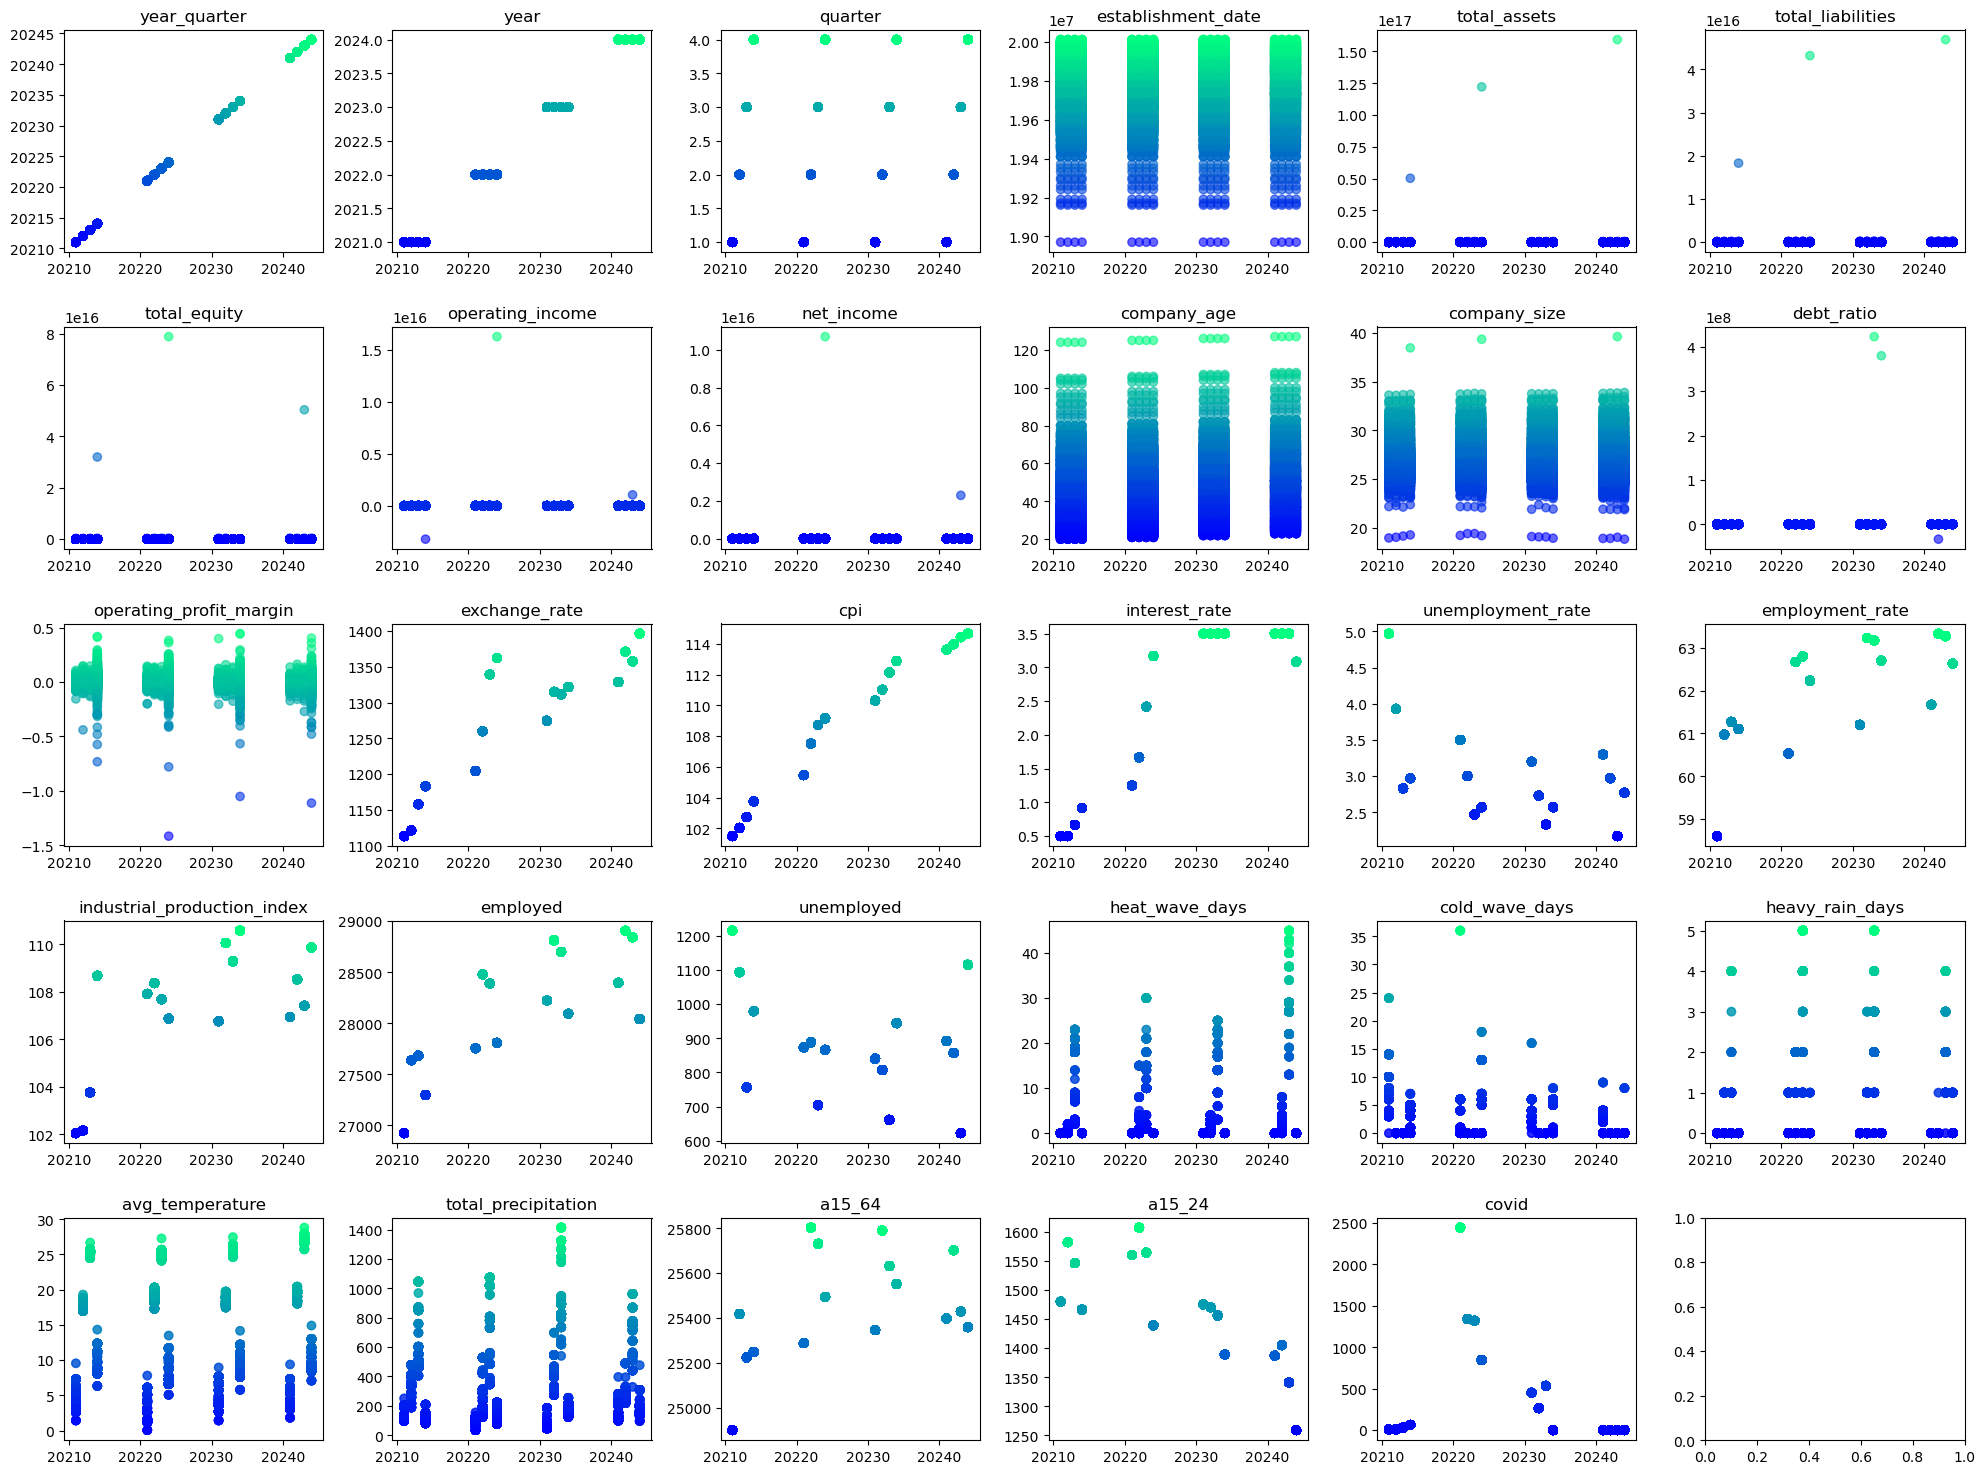

In [212]:
df_clean = df_clean.sort_values(by=['company_name', 'year_quarter'])

# num_features graph
fig, ax = plt.subplots(5, 6)

# grid size settings
fig.set_size_inches((20, 15))

# grig blank settings
plt.subplots_adjust(wspace=0.3, hspace=0.3)

for row in range(5):
    for col in range(6):
        
        if row * 6 + col > len(num_features)-1 : break

        ax[row, col].scatter(df_clean['year_quarter'] ,df_clean[num_features[row * 6 + col]], c=df_clean[num_features[row * 6 + col]],cmap='winter', alpha=0.6)
        ax[row, col].set_title(num_features[row * 6 + col])
        
plt.tight_layout()
plt.show()

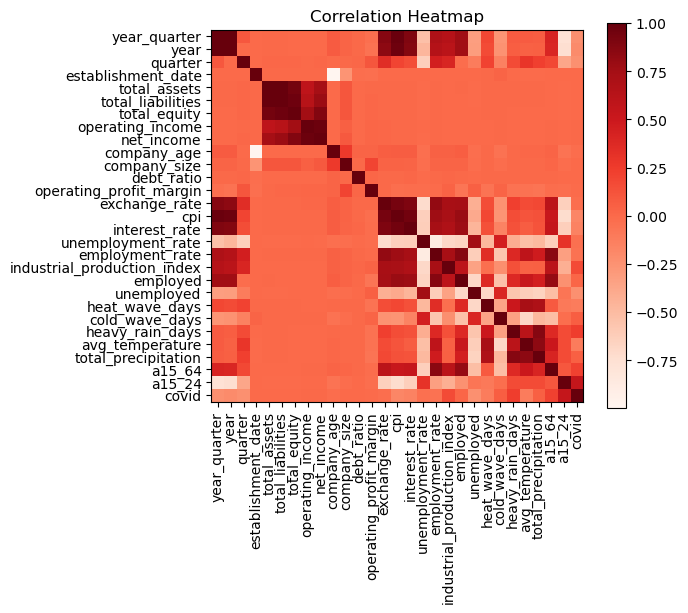

In [213]:
corr = df_clean[num_features].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr[num_features], cmap='Reds')

plt.colorbar()
plt.xticks(range(len(num_features)), num_features, rotation=90)
plt.yticks(range(len(num_features)), num_features)

plt.title("Correlation Heatmap")
plt.show()

In [214]:
# threshold 설정
threshold = 0.8

# 상관행렬 절댓값
corr_matrix = corr.abs()

# 상삼각 행렬만 사용 (중복 제거)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# threshold 이상인 feature 쌍 찾기
high_corr_pairs = [
    (column, row, upper.loc[row, column])
    for column in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, column]) and upper.loc[row, column] > threshold
]
# 결과 출력
for f1, f2, value in high_corr_pairs:
    print(f"{f1}  <->  {f2} : {value:.3f}")

year  <->  year_quarter : 0.995
total_liabilities  <->  total_assets : 0.996
total_equity  <->  total_assets : 0.941
total_equity  <->  total_liabilities : 0.969
net_income  <->  total_equity : 0.886
net_income  <->  operating_income : 0.971
company_age  <->  establishment_date : 0.997
exchange_rate  <->  year_quarter : 0.873
exchange_rate  <->  year : 0.842
cpi  <->  year_quarter : 0.980
cpi  <->  year : 0.965
cpi  <->  exchange_rate : 0.933
interest_rate  <->  year_quarter : 0.893
interest_rate  <->  year : 0.882
interest_rate  <->  exchange_rate : 0.902
interest_rate  <->  cpi : 0.946
employment_rate  <->  exchange_rate : 0.814
employment_rate  <->  unemployment_rate : 0.875
employed  <->  employment_rate : 0.873
total_precipitation  <->  heavy_rain_days : 0.873
total_precipitation  <->  avg_temperature : 0.841
a15_64  <->  employment_rate : 0.859
a15_64  <->  employed : 0.808
